# 📘 Explore_Timeseries.ipynb (converted to script format)

# === 📌 Notebook Cell 1: Introduction (Markdown) ===
"""
# 📊 Time Series Exploration: Tunisia Daily Temperature (1950–2025)

In this notebook, we will:

1. Load the processed daily average temperature dataset
2. Visualize the full time series
3. Analyze and decompose the signal (trend, seasonality, residuals)
4. Summarize insights before forecasting

Dataset Source: `data/processed/temperature_daily.csv`
"""

In [2]:
# === 📌 Notebook Cell 2: Import Required Libraries ===
import pandas as pd              # For data loading and manipulation
import matplotlib.pyplot as plt  # For plotting\import seaborn as sns            # For nice visual style
from statsmodels.tsa.seasonal import seasonal_decompose  # For time series decomposition
import seaborn as sns
# Set seaborn style for cleaner visuals
sns.set(style="whitegrid")

In [3]:
# === 📌 Notebook Cell 3: Load the Data ===
# Load the dataset with correct column names
data_path = r"C:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\processed\temperature_hourly.csv"
df = pd.read_csv(data_path, parse_dates=["datetime"], index_col="datetime")

# Preview the first few rows
print("📋 Preview of dataset:")
print(df.head())

📋 Preview of dataset:
                       temp_c
datetime                     
1950-01-01 00:00:00  9.214073
1950-01-01 01:00:00  8.844745
1950-01-01 02:00:00  8.540420
1950-01-01 03:00:00  8.202352
1950-01-01 04:00:00  7.762058


 === 📌 Notebook Cell 4: Basic Info (Markdown) ===
"""
## ℹ️ Dataset Overview
We loaded a time-indexed dataset with one column:
- `temp_c`: Average temperature over Tunisia (°C)

Each row corresponds to a **daily average** from 1950 to 2025.
"""

C:\Users\yosrc\AppData\Local\Temp\ipykernel_24068\741508340.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


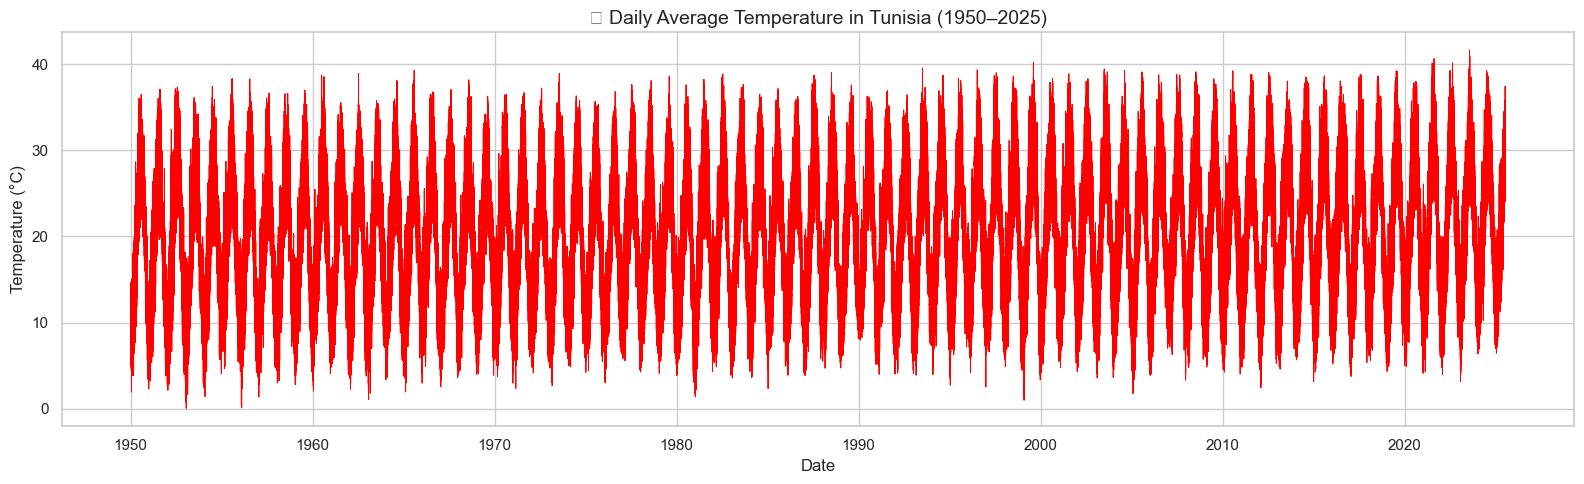

In [4]:
# === 📌 Notebook Cell 5: Plot the Full Time Series ===
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["temp_c"], color="red", linewidth=0.7)
plt.title("📈 Daily Average Temperature in Tunisia (1950–2025)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### 🔍 Observations from Daily Temperature Plot (1950–2025)

- The daily average temperature shows a **clear seasonal cycle**, repeating every year with peaks in summer and lows in winter.
- There's also a noticeable **long-term upward trend**, especially visible after the 1990s.
- These patterns indicate that the temperature series is **not stationary**, due to the presence of:
  - **Trend** (increasing over decades)
  - **Seasonality** (yearly cycles)

➡️ This confirms we’ll need to handle both **trend** and **seasonality** before applying time series models like ARIMA or LSTM.


# === 📌 Notebook Cell 6: Decomposition Intro (Markdown) ===
"""
## 🔍 Seasonal Decomposition

We will decompose the time series using the **Additive Model** to analyze:
- **Trend**: Long-term increase/decrease in temperature
- **Seasonality**: Repeating yearly pattern
- **Residuals**: What's left after removing trend + seasonality

We use `seasonal_decompose()` from `statsmodels`.
"""

In [5]:
# === 📌 Notebook Cell 7: Resample to Monthly Averages (for smoothness) ===
df_monthly = df["temp_c"].resample("M").mean()

C:\Users\yosrc\AppData\Local\Temp\ipykernel_24068\847089103.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df["temp_c"].resample("M").mean()


In [6]:
# === 📌 Notebook Cell 8: Apply Seasonal Decomposition ===
decomposition = seasonal_decompose(df_monthly, model="additive")

C:\Users\yosrc\AppData\Local\Temp\ipykernel_24068\1443664577.py:5: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


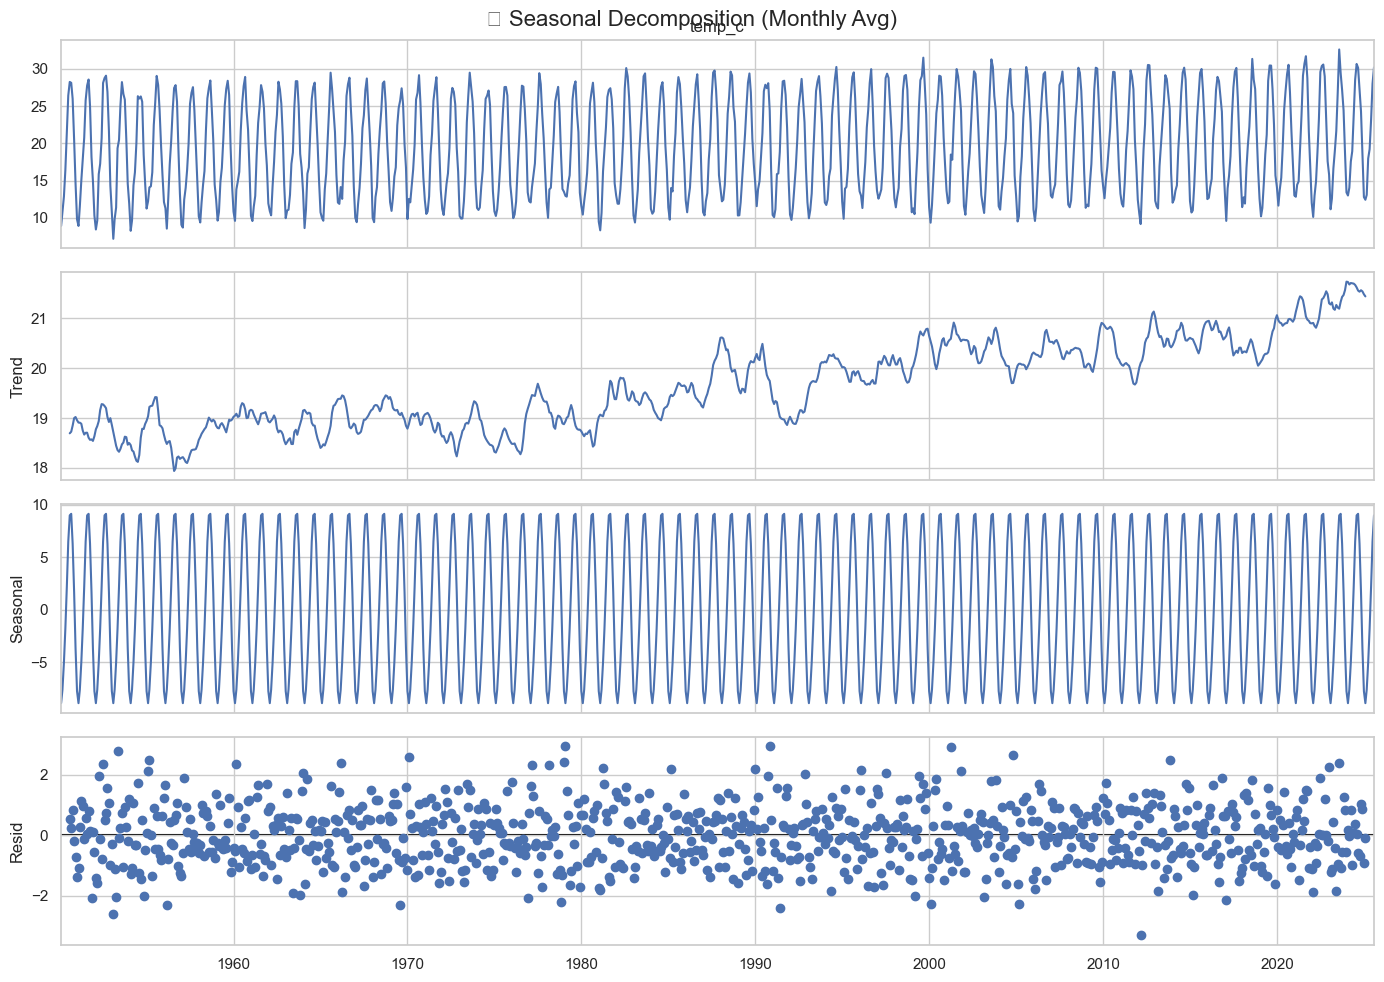

In [7]:
# === 📌 Notebook Cell 9: Plot the Decomposition ===
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("🔬 Seasonal Decomposition (Monthly Avg)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


### 🔍 Seasonal Decomposition Insights (Using Monthly Averages)

This decomposition breaks the series into 4 parts:

1. **Observed**: Smoothed monthly temperature values.
2. **Trend**:
   - Shows a **gradual increase in temperature** over the decades.
   - Confirms a **warming trend** in Tunisia from ~1950 to 2025.
3. **Seasonal**:
   - Strong **annual pattern** with high regularity.
   - Peaks in **July–August** (summer), drops in **January** (winter).
4. **Residual**:
   - Appears as **random noise**.
   - Indicates most of the structure is captured by trend + seasonal components.

➡️ This reinforces the need for **seasonal-aware models** (like SARIMA, Prophet), or **stationarity transformation** for ARIMA-type methods.
